In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()
print(df.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [4]:
print(df["TotalCharges"].dtype)
print((df["TotalCharges"].str.strip() == "").sum())

str
11


In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [6]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df = df.drop(columns="customerID")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
print(df.isnull().sum().sum())
df.head()

0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


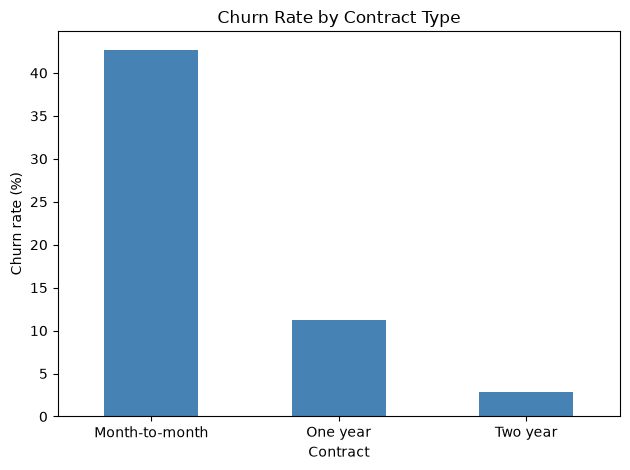

In [7]:
import matplotlib.pyplot as plt

contract_churn = df.groupby("Contract")["Churn"].mean() * 100
print(contract_churn.round(1))

contract_churn.plot(kind="bar", color="steelblue")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

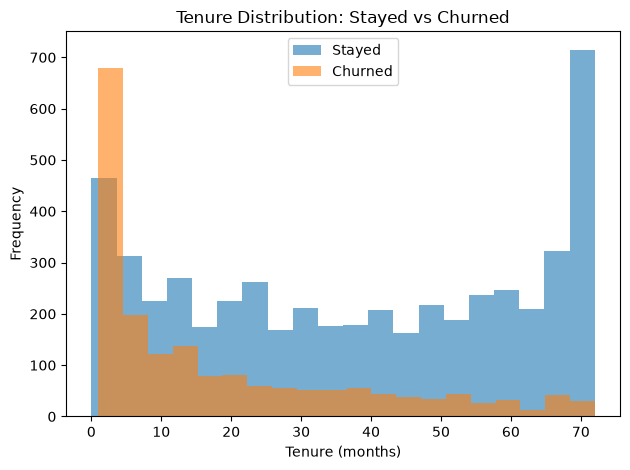

In [8]:
df[df["Churn"] == 0]["tenure"].plot(kind="hist", bins=20, alpha=0.6, label="Stayed")
df[df["Churn"] == 1]["tenure"].plot(kind="hist", bins=20, alpha=0.6, label="Churned")
plt.title("Tenure Distribution: Stayed vs Churned")
plt.xlabel("Tenure (months)")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
for col in ["InternetService", "PaymentMethod"]:
    print((df.groupby(col)["Churn"].mean() * 100).round(1))
    print()

InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64

PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: Churn, dtype: float64



In [10]:
categorical_cols = df.select_dtypes(include="str").columns

print(categorical_cols)
print("Number of categorical columns:", len(categorical_cols))

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')
Number of categorical columns: 15


In [11]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print(df_encoded.shape)
df_encoded.head()

(7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [12]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 30)
y shape: (7043,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [15]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8069552874378992
Accuracy (%): 80.69552874378992


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



[[925 110]
 [162 212]]


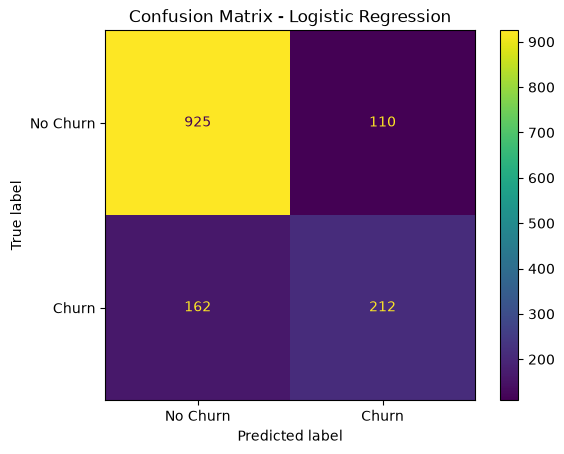

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [20]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:20])

[0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0]


In [21]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.57      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409



In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [23]:
gb_pred = gb_model.predict(X_test)

print(gb_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [25]:
!pip install xgboost
import xgboost

print(xgboost.__version__)

Defaulting to user installation because normal site-packages is not writeable
3.4.1


In [26]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed!")

XGBoost training completed!


In [27]:
xgb_pred = xgb_model.predict(X_test)

print(xgb_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [29]:
from sklearn.metrics import roc_auc_score

lr_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, lr_prob))

Logistic Regression ROC-AUC: 0.841778397788628


In [30]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Logistic Regression:", roc_auc_score(y_test, lr_prob))
print("Random Forest:", roc_auc_score(y_test, rf_prob))
print("Gradient Boosting:", roc_auc_score(y_test, gb_prob))
print("XGBoost:", roc_auc_score(y_test, xgb_prob))

Logistic Regression: 0.841778397788628
Random Forest: 0.8275013562737348
Gradient Boosting: 0.8421710713270816
XGBoost: 0.8440401457025498


In [31]:
import numpy as np
from sklearn.metrics import classification_report

lr_prob = model.predict_proba(X_test_scaled)[:, 1]

lr_pred_040 = (lr_prob >= 0.40).astype(int)

print(classification_report(y_test, lr_pred_040))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [32]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.20, 0.61, 0.05)

for threshold in thresholds:
    pred = (lr_prob >= threshold).astype(int)
    recall = ((pred == 1) & (y_test == 1)).sum() / (y_test == 1).sum()
    f1 = f1_score(y_test, pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.20 | Recall: 0.86 | F1: 0.60
Threshold: 0.25 | Recall: 0.81 | F1: 0.62
Threshold: 0.30 | Recall: 0.75 | F1: 0.62
Threshold: 0.35 | Recall: 0.71 | F1: 0.62
Threshold: 0.40 | Recall: 0.67 | F1: 0.61
Threshold: 0.45 | Recall: 0.61 | F1: 0.61
Threshold: 0.50 | Recall: 0.57 | F1: 0.61
Threshold: 0.55 | Recall: 0.47 | F1: 0.55
Threshold: 0.60 | Recall: 0.40 | F1: 0.51


[[774 261]
 [ 92 282]]


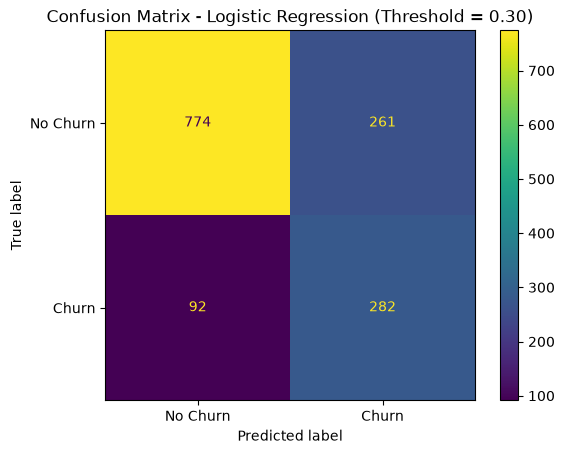

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_threshold = 0.30

final_pred = (lr_prob >= best_threshold).astype(int)

cm = confusion_matrix(y_test, final_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression (Threshold = 0.30)")
plt.show()

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall   :", recall_score(y_test, final_pred))
print("F1 Score :", f1_score(y_test, final_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_prob))

Accuracy : 0.7494677075940384
Precision: 0.5193370165745856
Recall   : 0.7540106951871658
F1 Score : 0.6150490730643402
ROC-AUC  : 0.841778397788628


In [35]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(feature_importance.head(15))

                                 Feature  Coefficient  Absolute_Coefficient
1                                 tenure    -1.236528              1.236528
2                         MonthlyCharges    -0.920153              0.920153
10           InternetService_Fiber optic     0.776154              0.776154
25                     Contract_Two year    -0.586859              0.586859
3                           TotalCharges     0.514285              0.514285
24                     Contract_One year    -0.285509              0.285509
23                   StreamingMovies_Yes     0.257227              0.257227
21                       StreamingTV_Yes     0.257144              0.257144
9                      MultipleLines_Yes     0.216167              0.216167
26                  PaperlessBilling_Yes     0.182034              0.182034
28        PaymentMethod_Electronic check     0.181103              0.181103
13                    OnlineSecurity_Yes    -0.123561              0.123561
6           

In [36]:
import joblib

joblib.dump(model, "churn_logistic_model.pkl")
joblib.dump(scaler, "churn_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [37]:
import os

print(os.path.exists("churn_logistic_model.pkl"))
print(os.path.exists("churn_scaler.pkl"))

True
True


In [38]:
def predict_churn(customer_data):
    
    # Convert input into DataFrame
    customer_df = pd.DataFrame([customer_data])
    
    # One-hot encode categorical columns
    customer_df = pd.get_dummies(
        customer_df,
        columns=categorical_cols,
        drop_first=True,
        dtype=int
    )
    
    # Make sure input has exactly the same columns as training data
    customer_df = customer_df.reindex(
        columns=X.columns,
        fill_value=0
    )
    
    # Scale the data
    customer_scaled = scaler.transform(customer_df)
    
    # Get churn probability
    probability = model.predict_proba(customer_scaled)[0][1]
    
    # Use our selected threshold
    prediction = 1 if probability >= 0.30 else 0
    
    if prediction == 1:
        result = "Churn"
    else:
        result = "No Churn"
    
    return result, probability

In [39]:
customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 70.0,
    "TotalCharges": 140.0
}

result, probability = predict_churn(customer)

print("Prediction:", result)
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: No Churn
Churn Probability: 17.93 %


In [40]:
high_risk_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 1,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 90.0,
    "TotalCharges": 90.0
}

result, probability = predict_churn(high_risk_customer)

print("Prediction:", result)
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: No Churn
Churn Probability: 10.98 %


In [41]:
print("Training columns:", len(X.columns))
print("Customer columns after encoding:")

test_customer_df = pd.DataFrame([high_risk_customer])

test_customer_df = pd.get_dummies(
    test_customer_df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print(test_customer_df.columns.tolist())

Training columns: 30
Customer columns after encoding:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [42]:
test_customer_df = pd.DataFrame([high_risk_customer])

print(test_customer_df.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [43]:
categorical_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

print("Number of categorical columns:", len(categorical_cols))

Number of categorical columns: 15


In [44]:
test_customer_df = pd.DataFrame([high_risk_customer])

test_customer_df = pd.get_dummies(
    test_customer_df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("Columns after encoding:", len(test_customer_df.columns))
print(test_customer_df.columns.tolist())

Columns after encoding: 4
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [45]:
def predict_churn(customer_data):

    customer_df = pd.DataFrame([customer_data])

    # Use the same categories as the original training data
    for col in categorical_cols:
        customer_df[col] = pd.Categorical(
            customer_df[col],
            categories=sorted(df[col].unique())
        )

    # One-hot encode using training categories
    customer_df = pd.get_dummies(
        customer_df,
        columns=categorical_cols,
        drop_first=True,
        dtype=int
    )

    # Match training feature columns exactly
    customer_df = customer_df.reindex(
        columns=X.columns,
        fill_value=0
    )

    # Scale using the same scaler
    customer_scaled = scaler.transform(customer_df)

    # Predict probability
    probability = model.predict_proba(customer_scaled)[0][1]

    # Our selected threshold
    prediction = 1 if probability >= 0.30 else 0

    result = "Churn" if prediction == 1 else "No Churn"

    return result, probability

In [46]:
row = df.drop(columns="Churn").iloc[0].to_dict()
_, p_func = predict_churn(row)
p_model = model.predict_proba(scaler.transform(X.iloc[[0]]))[0][1]
print(p_func, p_model)

0.6124709157065749 0.6124709157065749


In [47]:
result, probability = predict_churn(high_risk_customer)

print("Prediction:", result)
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: Churn
Churn Probability: 78.61 %


In [48]:
import sklearn
import pandas
import numpy
import matplotlib
import xgboost
import joblib


print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("xgboost:", xgboost.__version__)
print("joblib:", joblib.__version__)

pandas: 3.0.3
numpy: 2.4.6
scikit-learn: 1.9.0
matplotlib: 3.11.0
xgboost: 3.4.1
joblib: 1.5.3
